# Welcome to **UTD**Quake
[![UTDQuake](https://img.shields.io/badge/UTD-Quake-black?labelColor=orange&style=flat)](https://utdquake.readthedocs.io/en/latest/index.html)
[![Hugging Face Dataset](https://img.shields.io/badge/HuggingFace-Dataset-yellow?style=flat&logo=huggingface&logoColor=black?style=social)](https://huggingface.co/datasets/ecastillot/UTDQuake)
[![PyPI](https://img.shields.io/pypi/v/utdquake?color=blue&label=PyPI&style=flat)](https://pypi.org/project/utdquake/)
[![GitHub](https://img.shields.io/badge/GitHub-UTDQuake-black?logo=github)](https://github.com/ecastillot/UTDQuake)
![GitHub stars](https://img.shields.io/github/stars/ecastillot/UTDQuake?style=social)

A global earthquake dataset constructed from high-quality source and receiver metadata, including associated seismic phase picks across diverse station geometries.

> **Note:** It does not include waveforms by the moment, however curated datasets of earthquake events and phase picks are essential for modern seismology, especially in the AI era. While waveform datasets have advanced earthquake detection, multistation picks provide complementary information crucial for phase association and earthquake location.

## Overview

- More than 360K earthquakes, 12M picks (5.1M P & 2.4 S picks), and data from about 50K stations worldwide.
- More than 80 networks over the world with diverse distribution in:
  - Station density, Station geometry, Earthquake Epicentral location, Earthquake Depth, Earthquake Azimuthal gap, Number of P and S picks, Medium properties (Vp/Vs)

## Content
This guide provides a basic overview of [`UTDQuake`](https://github.com/ecastillot/UTDQuake) and demonstrates how to access datasets, networks, events, and visualizations. You can also see the documentation here: [![Read the Docs](https://img.shields.io/readthedocs/utdquake?style=for-the-badge&style=flat)](https://utdquake.readthedocs.io/en/latest/index.html)

Sections in this notebook:

- 📦 **Installation**
- 📊 **Dataset**
- ⚡ **Quick Access**
    - **Network**
    - **Events**
    - **Stations**
    - **Picks**
    - **Banks**
    - **Plots**
- ✍️ **Authors**

## Installation

You can install `UTDQuake` directly from PyPI using pip. This will install the Python package and its dependencies.

In [1]:
!pip install utdquake

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.1/117.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.9/344.9 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 84.6 MB/s eta 0:00:00


> **Note:** If you are using Google Colab, make sure to **restart the runtime** after installation.


# Dataset

The **UTDQuake Dataset** contains all the seismic data used in this project. You can explore its full structure and details here: [Dataset Structure](https://utdquake.readthedocs.io/en/latest/dataset.html).

To get started, first create an instance of the [`Dataset`](https://utdquake.readthedocs.io/en/latest/api/utdquake.html#utdquake.Dataset) class:

In [1]:
import utdquake as utdq

# dataset overview
dataset = utdq.Dataset(das=False)
print(dataset)

UTDQuake(root=/root/.utdquake)


> **Note:** `UTDQuake` requires a dedicated directory (***root***) to store all downloaded data, including datasets, networks, stations, and events. **By default, this directory is created inside your home folder**. If you prefer to use a different location, you can specify a custom path using the UTDQUAKE_ROOT environment variable or UTDQuake_DAS_ROOT for das dataset. This is explained in the [Configuration](https://utdquake.readthedocs.io/en/latest/installation.html#:~:text=import%20os%0Aos.environ%5B%22UTDQUAKE_ROOT%22%5D%20%3D%20%22/my/custom/path/for/utdquake_data%22) section.

You can access metadata for all available networks directly from the dataset.  
This returns a pandas `DataFrame` containing general information about each network.

In [2]:
# network level
network_data = dataset.networks
display(network_data)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/16.0k [00:00<?, ?B/s]

network/network.parquet:   0%|          | 0.00/26.3k [00:00<?, ?B/s]

Generating metadata split:   0%|          | 0/82 [00:00<?, ? examples/s]

,network,continent,provider,provider_url,country,agency,total_stations,located_stations,confirmed_stations,calculated_stations,...,events,p_arrivals,s_arrivals,start_time,end_time,approx_lon_min,approx_lon_max,approx_lat_min,approx_lat_max,score
0,AEIC,North America,ISC,http://www.isc.ac.uk,U.S.A.,Alaska Earthquake Information Center,670,568,340,277,...,4991,10150,3073,2018-07-20 05:09:59.400000,2024-12-28 14:29:57.590000,-180.000000,-130.00000,50.000000,72.000000,5.0
1,AFAD,Middle East,ISC,http://www.isc.ac.uk,Turkey,Disaster and Emergency Management Presidency,1130,766,226,549,...,4958,54279,44323,2024-09-22 01:52:19.000000,2024-12-31 06:47:02.000000,21.357400,49.09560,32.693200,44.570800,5.0
2,ANF,North America,ISC,http://www.isc.ac.uk,U.S.A.,USArray Array Network Facility,384,266,0,266,...,4987,45915,46410,2017-06-21 06:57:07.900000,2020-07-31 22:39:39.470000,-180.000000,-90.71848,22.860080,83.609020,5.0
3,ATH,Europe,ISC,http://www.isc.ac.uk,Greece,National Observatory of Athens,1325,996,800,532,...,4065,143563,76871,2024-04-19 00:05:16.500000,2024-06-30 23:59:32.600000,17.052200,31.48480,32.388000,43.476000,5.0
4,AUST,Oceania,ISC,http://www.isc.ac.uk,Australia,Geoscience Australia,2983,1676,1605,155,...,4777,104512,26059,2018-04-26 08:21:02.380000,2025-07-31 23:24:56.360000,-180.000000,180.00000,-84.175940,67.192340,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,se,North America,USGS,http://earthquake.usgs.gov,U.S.A.,Southeastern Seismic Network,338,332,327,167,...,2147,24786,11822,2012-09-30 19:46:01.990000,2025-07-27 04:16:14.290000,-90.829933,-74.26140,30.493160,42.088707,4.0
78,tx,North America,USGS,http://earthquake.usgs.gov,U.S.A.,Texas Seismic Network,323,318,304,279,...,5000,110530,118694,2025-01-14 10:18:25.227326,2025-07-31 23:29:28.716900,-106.592000,-92.91400,26.793800,37.036200,5.0
79,us,World,USGS,http://earthquake.usgs.gov,U.S.A.,United States National Network,3408,3307,3294,892,...,4997,186610,12179,2025-06-22 23:34:27.533000,2025-07-31 23:59:53.390000,-180.000000,180.00000,-90.000000,90.000000,5.0
80,uu,North America,USGS,http://earthquake.usgs.gov,U.S.A.,Utah University Network,259,259,259,208,...,5000,63792,25247,2024-02-21 20:08:02.880000,2025-07-31 13:13:29.800000,-115.360320,-107.64058,35.090467,46.783033,5.0


In [3]:
dataset.get_stations()

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

stations/network=AEIC.parquet:   0%|          | 0.00/58.3k [00:00<?, ?B/s]

stations/network=ATH.parquet:   0%|          | 0.00/98.9k [00:00<?, ?B/s]

stations/network=AFAD.parquet:   0%|          | 0.00/67.5k [00:00<?, ?B/s]

...

stations/network=tx.parquet:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

stations/network=pr.parquet:   0%|          | 0.00/17.7k [00:00<?, ?B/s]

stations/network=uw.parquet:   0%|          | 0.00/71.9k [00:00<?, ?B/s]

Generating metadata split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['network', 'station', 'available', 'confirmed', 'confirmed_latitude', 'confirmed_longitude', 'confirmed_elevation', 'calculated', 'calculated_latitude', 'calculated_longitude', 'calculated_latitude_std', 'calculated_longitude_std', 'creation_time', 'calculated_num_entries', 'db_path'],
    num_rows: 63654
})

In [4]:
dataset.description

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

events/network=BER.parquet:   0%|          | 0.00/323k [00:00<?, ?B/s]

...

events/network=us.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

events/network=uw.parquet:   0%|          | 0.00/559k [00:00<?, ?B/s]

events/network=uu.parquet:   0%|          | 0.00/485k [00:00<?, ?B/s]

Generating metadata split: 0 examples [00:00, ? examples/s]

{'events': 346487,
 'p_arrivals': 5065366,
 's_arrivals': 2423829,
 'total_stations': 57098,
 'located_stations': 42457,
 'confirmed_stations': 35220,
 'calculated_stations': 16751,
 'start_time': '2010-01-01 04:30:32.770000',
 'end_time': '2025-07-31 23:59:53.390000'}

In addition to network-level access, the dataset allows you to retrieve aggregated information across multiple networks. You can directly access events, stations, and picks using the following methods:

[`utdquake.Dataset.get_events()`](https://utdquake.readthedocs.io/en/latest/api/utdquake.html#utdquake.Dataset:~:text=a%20Pandas%20DataFrame.-,get_events,-(network%3D)  – Retrieve event information across networks

[`utdquake.Dataset.get_stations()`](https://utdquake.readthedocs.io/en/latest/api/utdquake.html#utdquake.Dataset:~:text=a%20specific%20network.-,get_stations,-(network%3D)  – Retrieve station metadata across networks

[`utdquake.Dataset.get_picks()`](https://utdquake.readthedocs.io/en/latest/api/utdquake.html#utdquake.Dataset:~:text=given%20network%20name.-,get_picks,-(network%3D)  – Retrieve seismic phase picks across networks. Uses streaming=True because the dataset is large (>12M entries) and must be processed iteratively.



In [5]:
picks = dataset.get_picks()
for i, row in enumerate(picks):
  if i >= 10:
    break
  print(row)

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

{'network': 'IR', 'station': 'SPWE', 'phase': 'Pg', 'time': Timestamp('2019-07-24 18:26:18.020000'), 'travel_time': 1.27, 'travel_time_zscore': 1.0401954615574078, 'distance': 0.027, 'linear_hyp_distance': 3.0021299999999997, 'azimuth': 237.401, 'evaluation_mode': None, 'event_id': 'smi:ISC/evid=616650374', 'origin_time': Timestamp('2019-07-24 18:26:16.750000'), 'resource_id': 'smi:ISC/pickid=984018806/hypid=612707846', 'seed_id': 'IR.SPWE..', 'pick_id': 'smi:ISC/pickid=984018806', 'time_correction': None, 'takeoff_angle': None, 'time_residual': None, 'horizontal_slowness_residual': None, 'backazimuth_residual': None, 'time_weight': None, 'horizontal_slowness_weight': None, 'backazimuth_weight': None, 'earth_model_id': None, 'creation_time': None, 'author': None, 'agency_id': None, 'location': '', 'channel': '', 'origin_id': 'smi:ISC/origid=612707846', 'preferred_origin_id': 'smi:ISC/origid=612707846'}
{'network': 'IR', 'station': 'KCE', 'phase': 'Pg', 'time': Timestamp('2019-10-14 19:

# Quick Access

Easily retrieve detailed information for any specific network:



**Load a Network**  
You can load data for a specific network using its network code.  
Example: The Texas network corresponds to the code `"tx"`. This will return a [`Network`](https://utdquake.readthedocs.io/en/latest/api/utdquake.html#utdquake.Network)  class.

In [6]:
# load network
network = dataset.get_network(name="tx")
print(network)

Network(tx) | Events: 5000, Stations: 323


**Load Events**

In [7]:
# events
events = network.events
display(events)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

,time,latitude,longitude,depth,magnitude,azimuthal_gap,event_description,associated_phase_count,event_id,horizontal_uncertainty,...,used_phase_count,station_count,vertical_uncertainty,updated,author,agency_id,creation_time,version,stations,preferred_origin_id
0,2025-01-14 10:18:25.227326,31.962,-102.990,8618.2,1.8,35.177261,Western Texas,102.0,smi:org.gfz-potsdam.de/geofon/texnet2025aynz,1310.826018,...,23.0,60.0,4170.059130,2025-01-15 16:30:37.641257984,scevent@scdb.beg.utexas.edu,TX,2025-01-14 10:18:42.704152,<NA>,"ALPN, CL7, CPRX, DB04, DG07, DG10, GV01, JAL, ...",smi:org.gfz-potsdam.de/geofon/NLL.202501151627...
1,2025-01-14 12:19:34.106573,31.731,-104.092,6574.1,1.6,28.834083,Western Texas,90.0,smi:org.gfz-potsdam.de/geofon/texnet2025aysb,246.252967,...,57.0,53.0,333.727805,2025-01-14 13:32:37.408389120,scevent@scdb.beg.utexas.edu,TX,2025-01-14 12:19:41.243527,<NA>,"BP01, CT01, CT02, CV01, GDL2, LWM3, NM02, NMP0...",smi:org.gfz-potsdam.de/geofon/NLL.202501141332...
2,2025-01-14 12:24:25.285708,31.730,-104.093,5625.6,1.6,29.056512,Western Texas,88.0,smi:org.gfz-potsdam.de/geofon/texnet2025aysg,361.529462,...,33.0,59.0,651.628880,2025-01-14 13:24:55.225116928,scevent@scdb.beg.utexas.edu,TX,2025-01-14 12:24:34.741282,<NA>,"BP01, CL7, CPRX, CT01, CT02, CV01, DAG, GDL2, ...",smi:org.gfz-potsdam.de/geofon/NLL.202501141324...
3,2025-01-14 12:29:10.780642,31.612,-103.981,6856.1,1.6,72.688098,Western Texas,30.0,smi:org.gfz-potsdam.de/geofon/texnet2025aysk,392.490295,...,30.0,15.0,444.185241,2025-01-14 14:35:13.184786944,scevent@scdb.beg.utexas.edu,TX,2025-01-14 12:29:17.564955,<NA>,"PB12, PB13, PB20, PB23, PB24, PB25, PB31, PB33...",smi:org.gfz-potsdam.de/geofon/NLL.202501141434...
4,2025-01-14 12:48:52.850427,32.004,-103.846,7189.3,2.8,51.597369,New Mexico,55.0,smi:org.gfz-potsdam.de/geofon/texnet2025aytd,541.099288,...,50.0,29.0,585.458954,2025-01-14 13:09:41.987721984,scevent@scdb.beg.utexas.edu,TX,2025-01-14 12:49:01.657654,<NA>,"BP01, CT02, NMP01, NMP02, NMP11, NMP12, NMP31,...",smi:org.gfz-potsdam.de/geofon/NLL.202501141307...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2025-07-31 18:10:38.921959,31.863,-101.710,7983.4,1.0,81.516919,Western Texas,23.0,smi:org.gfz-potsdam.de/geofon/tx2025oysjnx,835.447353,...,19.0,12.0,1878.365909,2025-08-01 17:32:04.645430016,scevent@scdb.beg.utexas.edu,TX,2025-07-31 18:11:12.793309,<NA>,"AT01, CW01, GV03, M169, M213, MB01, MB03, MB06...",smi:org.gfz-potsdam.de/geofon/NLL.202508011731...
4996,2025-07-31 19:33:39.435961,32.104,-101.488,8935.5,0.9,56.670930,Western Texas,32.0,smi:org.gfz-potsdam.de/geofon/tx2025oyvcye,682.584806,...,30.0,17.0,950.269799,2025-08-01 14:23:39.685349888,scevent@scdb.beg.utexas.edu,TX,2025-07-31 19:33:52.907390,<NA>,"AT01, BW01, GV01, GV03, M044, M109, M138, M169...",smi:org.gfz-potsdam.de/geofon/NLL.202508011422...
4997,2025-07-31 20:21:57.031838,31.994,-101.362,4047.5,1.1,84.421808,Western Texas,31.0,smi:org.gfz-potsdam.de/geofon/tx2025oywsrr,894.456396,...,16.0,16.0,2476.537947,2025-08-01 16:04:26.142739968,scevent@scdb.beg.utexas.edu,TX,2025-07-31 23:11:46.636961,<NA>,"AT01, BW01, CW01, GV03, M044, M109, M169, M213...",smi:org.gfz-potsdam.de/geofon/NLL.202508011604...
4998,2025-07-31 22:38:18.041990,32.120,-101.109,8886.7,1.2,77.650412,Western Texas,30.0,smi:org.gfz-potsdam.de/geofon/tx2025ozbgeo,991.993617,...,23.0,18.0,1745.187011,2025-08-01 01:05:04.134597888,scevent@scdb.beg.utexas.edu,TX,2025-07-31 23:11:46.899452,<NA>,"APMT, BW01, GV01, GV03, M138, M213, MB03, MB13...",smi:org.gfz-potsdam.de/geofon/NLL.202508010104...


**Load Stations**

In [8]:
# stations
stations = network.stations
display(stations)

,network,station,available,confirmed,confirmed_latitude,confirmed_longitude,confirmed_elevation,calculated,calculated_latitude,calculated_longitude,calculated_latitude_std,calculated_longitude_std,creation_time,calculated_num_entries,db_path
0,tx,W35A,True,True,35.15274,-96.87453,322.0,False,NaN,NaN,NaN,NaN,2026-02-05 23:35:31.849310,<NA>,tx/.stations/.OK_W35A.db
1,tx,CBKS,True,True,38.81400,-99.73740,677.0,False,NaN,NaN,NaN,NaN,2026-02-05 23:35:31.730488,<NA>,tx/.stations/.US_CBKS.db
2,tx,AMTX,True,True,34.88370,-101.68080,1010.0,False,NaN,NaN,NaN,NaN,2026-02-05 23:35:31.817970,<NA>,tx/.stations/.US_AMTX.db
3,tx,WMOK,True,True,34.73790,-98.78070,486.0,False,NaN,NaN,NaN,NaN,2026-02-05 23:35:31.810278,<NA>,tx/.stations/.US_WMOK.db
4,tx,NAS3,True,False,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,2026-02-05 23:35:31.848599,<NA>,tx/.stations/.XX_NAS3.db
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,tx,GV03,True,True,32.11000,-101.63950,765.0,True,32.110037,-101.639410,0.000501,0.000714,2026-02-05 23:35:41.024706,515,tx/.stations/.4O_GV03.db
319,tx,BW01,True,True,32.35311,-101.25893,729.0,True,32.352765,-101.258639,0.000653,0.000855,2026-02-05 23:35:41.044809,491,tx/.stations/.4O_BW01.db
320,tx,M044,True,False,NaN,NaN,NaN,True,32.153893,-101.556134,0.000299,0.000268,2026-02-05 23:35:40.823929,293,tx/.stations/.SM_M044.db
321,tx,SGCY,True,True,31.91436,-101.12639,776.0,True,31.915066,-101.125508,0.000734,0.000938,2026-02-05 23:35:41.226598,662,tx/.stations/.TX_SGCY.db


**Load Picks**

In [9]:
picks = network.picks
display(picks)

,network,station,phase,time,travel_time,travel_time_zscore,distance,linear_hyp_distance,azimuth,evaluation_mode,...,horizontal_slowness_weight,backazimuth_weight,earth_model_id,creation_time,author,agency_id,location,channel,origin_id,preferred_origin_id
0,TX,DG04,P,2025-06-23 12:11:52.587038,0.522785,-0.811787,0.008236,1.745177,272.361616,manual,...,NaN,NaN,<NA>,NaT,<NA>,<NA>,00,CHR,smi:org.gfz-potsdam.de/geofon/NLL.202506241623...,smi:org.gfz-potsdam.de/geofon/NLL.202506241623...
1,TX,DG04,S,2025-06-23 12:11:53.188727,1.124474,-2.912755,0.008236,1.745177,272.361616,manual,...,NaN,NaN,<NA>,NaT,<NA>,<NA>,00,CH2,smi:org.gfz-potsdam.de/geofon/NLL.202506241623...,smi:org.gfz-potsdam.de/geofon/NLL.202506241623...
2,TX,PB30,S,2025-02-12 06:27:10.914895,1.267083,-1.193700,0.012861,1.758952,54.986356,manual,...,NaN,NaN,<NA>,NaT,<NA>,<NA>,00,HHN,smi:org.gfz-potsdam.de/geofon/NLL.202502121652...,smi:org.gfz-potsdam.de/geofon/NLL.202502121652...
3,TX,PB30,P,2025-02-12 06:27:10.160895,0.513083,-0.923899,0.012861,1.758952,54.986356,manual,...,NaN,NaN,<NA>,NaT,<NA>,<NA>,00,HHZ,smi:org.gfz-potsdam.de/geofon/NLL.202502121652...,smi:org.gfz-potsdam.de/geofon/NLL.202502121652...
4,TX,PB30,S,2025-01-26 14:51:41.053437,1.234062,-1.681886,0.012478,1.820053,78.939231,manual,...,NaN,NaN,<NA>,NaT,<NA>,<NA>,00,HHN,smi:org.gfz-potsdam.de/geofon/NLL.202501272157...,smi:org.gfz-potsdam.de/geofon/NLL.202501272157...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229206,TX,PLPT,P,2025-05-21 22:17:24.187314,59.450574,0.909985,3.796031,422.134076,130.375101,manual,...,NaN,NaN,<NA>,NaT,<NA>,<NA>,00,HHZ,smi:org.gfz-potsdam.de/geofon/NLL.202506011558...,smi:org.gfz-potsdam.de/geofon/NLL.202506011558...
229207,TX,PLPT,S,2025-05-21 22:18:05.972558,101.235818,-1.100265,3.796031,422.134076,130.375101,manual,...,NaN,NaN,<NA>,NaT,<NA>,<NA>,00,HH2,smi:org.gfz-potsdam.de/geofon/NLL.202506011558...,smi:org.gfz-potsdam.de/geofon/NLL.202506011558...
229208,IU,ANMO,S,2025-05-21 22:18:20.722702,115.985962,0.437531,3.877196,431.157682,265.731031,manual,...,NaN,NaN,<NA>,NaT,<NA>,<NA>,00,BH1,smi:org.gfz-potsdam.de/geofon/NLL.202506011558...,smi:org.gfz-potsdam.de/geofon/NLL.202506011558...
229209,TX,BRDY,P,2025-05-21 22:17:49.154198,84.417458,4.817373,4.641639,516.147555,149.494966,manual,...,NaN,NaN,<NA>,NaT,<NA>,<NA>,00,HH1,smi:org.gfz-potsdam.de/geofon/NLL.202506011558...,smi:org.gfz-potsdam.de/geofon/NLL.202506011558...


**Load Banks**

UTDQuake integrates an event bank. Check **ObsPlus** [`EventBank`](https://utdquake.readthedocs.io/en/latest/api/utdquake.html#utdquake.Network) for more details.

In [13]:
# get event bank
ebank = network.bank #
print("This is my Event Bank",ebank)

# Example: Filter by event_id
ev_ids = events["event_id"].iloc[:5].tolist()
cat = ebank.get_events(event_id=ev_ids)
print("First 5 earthquakes:", cat)

# Example 2: Other filter (check obsplus.EventBank for more details)
cat2 = ebank.get_events(minmagnitude=4.3)
print("Earthquakes above M4.3:",cat2)

This is my Event Bank EventBank(base_path=/root/.utdquake/banks/tx, index_path=/root/.utdquake/banks/tx/.index.db)
First 5 earthquakes: 5 Event(s) in Catalog:
2025-01-14T10:18:25.227326Z | +31.962, -102.990 | 1.8  ML | manual
2025-01-14T12:19:34.106573Z | +31.731, -104.092 | 1.6  ML | manual
2025-01-14T12:24:25.285708Z | +31.730, -104.093 | 1.6  ML | manual
2025-01-14T12:29:10.780642Z | +31.612, -103.981 | 1.6  ML | manual
2025-01-14T12:48:52.850427Z | +32.004, -103.846 | 2.8  ML | manual
Earthquakes above M4.3: 5 Event(s) in Catalog:
2025-05-04T01:47:05.553401Z | +31.647, -104.458 | 5.4  ML | manual
2025-02-28T19:33:24.297261Z | +32.370, -101.926 | 4.8  ML | manual
2025-02-18T12:16:28.873362Z | +31.711, -104.502 | 4.7  ML | manual
2025-02-15T05:23:21.429810Z | +31.661, -104.180 | 5.0  ML | manual
2025-01-30T03:26:36.879193Z | +29.058,  -97.846 | 4.6  ML | manual


You can also check them in dataframe

In [18]:
print("Events")
display(cat2.utdq_events_to_df())
print("Picks")
display(cat2.utdq_picks_to_df())

Events


,time,latitude,longitude,depth,magnitude,azimuthal_gap,event_description,associated_phase_count,event_id,horizontal_uncertainty,...,used_phase_count,station_count,vertical_uncertainty,updated,author,agency_id,creation_time,version,stations,preferred_origin_id
0,2025-05-04 01:47:05.553401,31.647,-104.458,7535.4,5.4,66.059033,Western Texas,101.0,smi:org.gfz-potsdam.de/geofon/texnet2025iqwk,2013.515612,...,16.0,57.0,633.206821,2025-05-04 03:28:11.981286912,scevent@scdb.beg.utexas.edu,TX,2025-05-04 01:47:11.535450,,"ALPN, BP01, CT01, CT02, CV01, GDL2, MNTX, NMP0...",smi:org.gfz-potsdam.de/geofon/NLL.202505040313...
1,2025-02-28 19:33:24.297261,32.370,-101.926,6811.5,4.8,26.835872,Western Texas,116.0,smi:org.gfz-potsdam.de/geofon/texnet2025edml,489.008328,...,51.0,73.0,1494.628678,2025-02-28 20:39:50.858385920,scevent@scdb.beg.utexas.edu,TX,2025-02-28 19:33:36.305374,,"AT01, BB01, BW01, CF01, CW01, DKNS, EE02, EE04...",smi:org.gfz-potsdam.de/geofon/NLL.202502281955...
2,2025-02-18 12:16:28.873362,31.711,-104.502,3895.3,4.7,64.966896,Western Texas,104.0,smi:org.gfz-potsdam.de/geofon/texnet2025dkql,598.031778,...,10.0,56.0,1122.082087,2025-02-18 19:18:10.177048064,scevent@scdb.beg.utexas.edu,TX,2025-02-18 12:16:38.070809,,"BP01, CL2B, CT01, CT02, CV01, DAG, DG07, DG08,...",smi:org.gfz-potsdam.de/geofon/NLL.202502181914...
3,2025-02-15 05:23:21.429810,31.661,-104.180,6099.9,5.0,58.635028,Western Texas,73.0,smi:org.gfz-potsdam.de/geofon/texnet2025deqh,634.105332,...,29.0,46.0,1011.025013,2025-02-15 18:06:07.500283904,scevent@scdb.beg.utexas.edu,TX,2025-02-15 05:23:30.816083,,"ALPN, BP01, CT01, CT02, CV01, LWM3, MNTX, PB01...",smi:org.gfz-potsdam.de/geofon/NLL.202502151801...
4,2025-01-30 03:26:36.879193,29.058,-97.846,6836.5,4.6,78.769675,Central Texas,68.0,smi:org.gfz-potsdam.de/geofon/texnet2025cbgl,584.431861,...,28.0,34.0,740.966956,2025-07-01 00:00:00.000000000,sceventfk@scdb.beg.utexas.edu,TX,2025-01-30 03:26:51.722719,,"735B, EF02, EF03, EF04, EF05, EF07, EF52, EF54...",smi:org.gfz-potsdam.de/geofon/NLL.202505232007...


Picks


,network,station,phase,time,travel_time,distance,linear_hyp_distance,azimuth,evaluation_mode,event_id,...,horizontal_slowness_weight,backazimuth_weight,earth_model_id,creation_time,author,agency_id,location,channel,origin_id,preferred_origin_id
0,2T,EF73,P,2025-01-30 03:26:40.660782,3.781589,0.087257,11.868823,210.546730,manual,smi:org.gfz-potsdam.de/geofon/texnet2025cbgl,...,NaN,NaN,,NaT,,,00,HHN,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...
1,2T,EF61,P,2025-01-30 03:26:41.636254,4.757061,0.137736,16.771512,299.179831,manual,smi:org.gfz-potsdam.de/geofon/texnet2025cbgl,...,NaN,NaN,,NaT,,,00,HHN,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...
2,TX,EF04,P,2025-01-30 03:26:41.924392,5.045199,0.159307,18.986888,17.949506,manual,smi:org.gfz-potsdam.de/geofon/texnet2025cbgl,...,NaN,NaN,,NaT,,,00,HH1,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...
3,TX,EF03,P,2025-01-30 03:26:42.195711,5.316518,0.162916,19.361729,226.387570,manual,smi:org.gfz-potsdam.de/geofon/texnet2025cbgl,...,NaN,NaN,,NaT,,,00,HH1,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...
4,TX,EF07,P,2025-01-30 03:26:42.268020,5.388827,0.167867,19.877710,243.875493,manual,smi:org.gfz-potsdam.de/geofon/texnet2025cbgl,...,NaN,NaN,,NaT,,,00,HHZ,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...,smi:org.gfz-potsdam.de/geofon/NLL.202505232007...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,US,MNTX,S,2025-05-04 01:47:30.420277,24.866876,0.789743,88.134259,273.970924,manual,smi:org.gfz-potsdam.de/geofon/texnet2025iqwk,...,NaN,NaN,,NaT,,,00,HH1,smi:org.gfz-potsdam.de/geofon/NLL.202505040313...,smi:org.gfz-potsdam.de/geofon/NLL.202505040313...
458,TX,ALPN,P,2025-05-04 01:47:31.154040,25.600639,1.450892,161.500580,150.772143,manual,smi:org.gfz-potsdam.de/geofon/texnet2025iqwk,...,NaN,NaN,,NaT,,,00,HHZ,smi:org.gfz-potsdam.de/geofon/NLL.202505040313...,smi:org.gfz-potsdam.de/geofon/NLL.202505040313...
459,TX,PB01,S,2025-05-04 01:47:33.882084,28.328683,0.909788,101.439582,140.252926,manual,smi:org.gfz-potsdam.de/geofon/texnet2025iqwk,...,NaN,NaN,,NaT,,,00,HH1,smi:org.gfz-potsdam.de/geofon/NLL.202505040313...,smi:org.gfz-potsdam.de/geofon/NLL.202505040313...
460,TX,VHRN,S,2025-05-04 01:47:35.802302,30.248901,0.969468,108.058220,207.911891,manual,smi:org.gfz-potsdam.de/geofon/texnet2025iqwk,...,NaN,NaN,,NaT,,,00,HH2,smi:org.gfz-potsdam.de/geofon/NLL.202505040313...,smi:org.gfz-potsdam.de/geofon/NLL.202505040313...


**Predict Travel Time**

We created a travel time model for each network based on the information provided by the catalog

In [23]:
tt = network.travel_time
predictions = tt.predict(phase="P", distance=[2,3,4,5,10,20,30,40,50,60]) #in km
display(predictions)

,distance,travel_time_sigma,travel_time_p1,travel_time_p25,travel_time_p50,travel_time_p75,travel_time_p99
0,2,0.137641,0.360441,0.577918,0.660959,0.767933,0.923639
1,3,0.285052,0.159690,0.693867,0.895914,1.077015,1.467742
2,4,0.294518,0.254162,0.888233,1.154796,1.330661,1.717080
3,5,0.303984,0.348633,1.082600,1.413678,1.584306,1.966418
4,10,0.411020,1.153689,1.907476,2.219584,2.479289,3.241444
5,20,0.520890,2.797384,3.581816,3.892948,4.312482,5.757520
6,30,0.673557,4.336573,5.190711,5.603822,6.122897,7.924097
7,40,0.830987,5.780175,6.789612,7.301463,7.947344,10.189669
8,50,0.958528,7.278227,8.326234,8.904598,9.674086,12.506897
9,60,1.059478,8.862001,9.900596,10.529077,11.389062,14.471681


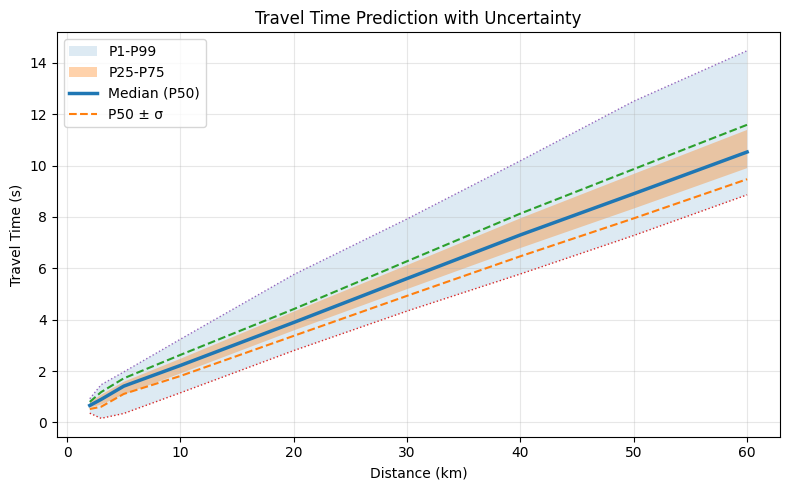

In [24]:
#plot predictions

import pandas as pd
import matplotlib.pyplot as plt

df = predictions

fig, ax = plt.subplots(figsize=(8, 5))

# Main prediction interval (1%-99%)
ax.fill_between(
    df["distance"],
    df["travel_time_p1"],
    df["travel_time_p99"],
    alpha=0.15,
    label="P1-P99"
)

# Interquartile range (25%-75%)
ax.fill_between(
    df["distance"],
    df["travel_time_p25"],
    df["travel_time_p75"],
    alpha=0.35,
    label="P25-P75"
)

# Median prediction
ax.plot(
    df["distance"],
    df["travel_time_p50"],
    lw=2.5,
    label="Median (P50)"
)

# ±1 sigma
ax.plot(
    df["distance"],
    df["travel_time_p50"] - df["travel_time_sigma"],
    "--",
    lw=1.5,
    label="P50 ± σ"
)

ax.plot(
    df["distance"],
    df["travel_time_p50"] + df["travel_time_sigma"],
    "--",
    lw=1.5
)

# Optional percentile curves
ax.plot(df["distance"], df["travel_time_p1"],  ":", lw=1)
ax.plot(df["distance"], df["travel_time_p99"], ":", lw=1)

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Travel Time (s)")
ax.set_title("Travel Time Prediction with Uncertainty")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Plots**

UTDQuake provides convenient plotting functions for quick data exploration. Check the [`utdquake.Network()`](https://utdquake.readthedocs.io/en/latest/api/utdquake.html#utdquake.Network.plot_overview) plotting functions for more details and examples. Or also check the [`utdquake.utils.plot()`](https://utdquake.readthedocs.io/en/latest/api/utils.html#utdquake-utils-plot) module for more flexibility to create your own custom plots.

> **Note:**
We need [`Cartopy`](https://cartopy.readthedocs.io/stable/) to be able to plot most of the figures.

This installation takes time in Colab (be patient! 🙂). However, shouldn't be like that in your laptop.

In [ ]:
import sys
if 'google.colab' in sys.modules:
    !sudo apt update
    !sudo apt upgrade -y
    !sudo apt install -y build-essential cmake libcurl4-gnutls-dev libnetcdf-dev gdal-bin libgdal-dev libfftw3-dev libpcre3-dev liblapack-dev libblas-dev libglib2.0-dev ghostscript ghostscript-x graphicsmagick ffmpeg xdg-utils
    # clone gmt from source
    !git clone --depth 50 https://github.com/GenericMappingTools/gmt
    # cmake everything
    !cmake /content/gmt
    # build and install
    !cmake --build . --target install
    !pip install cartopy

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,701 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,297 kB]
Get:

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWar

Saved plot to utdquake.png


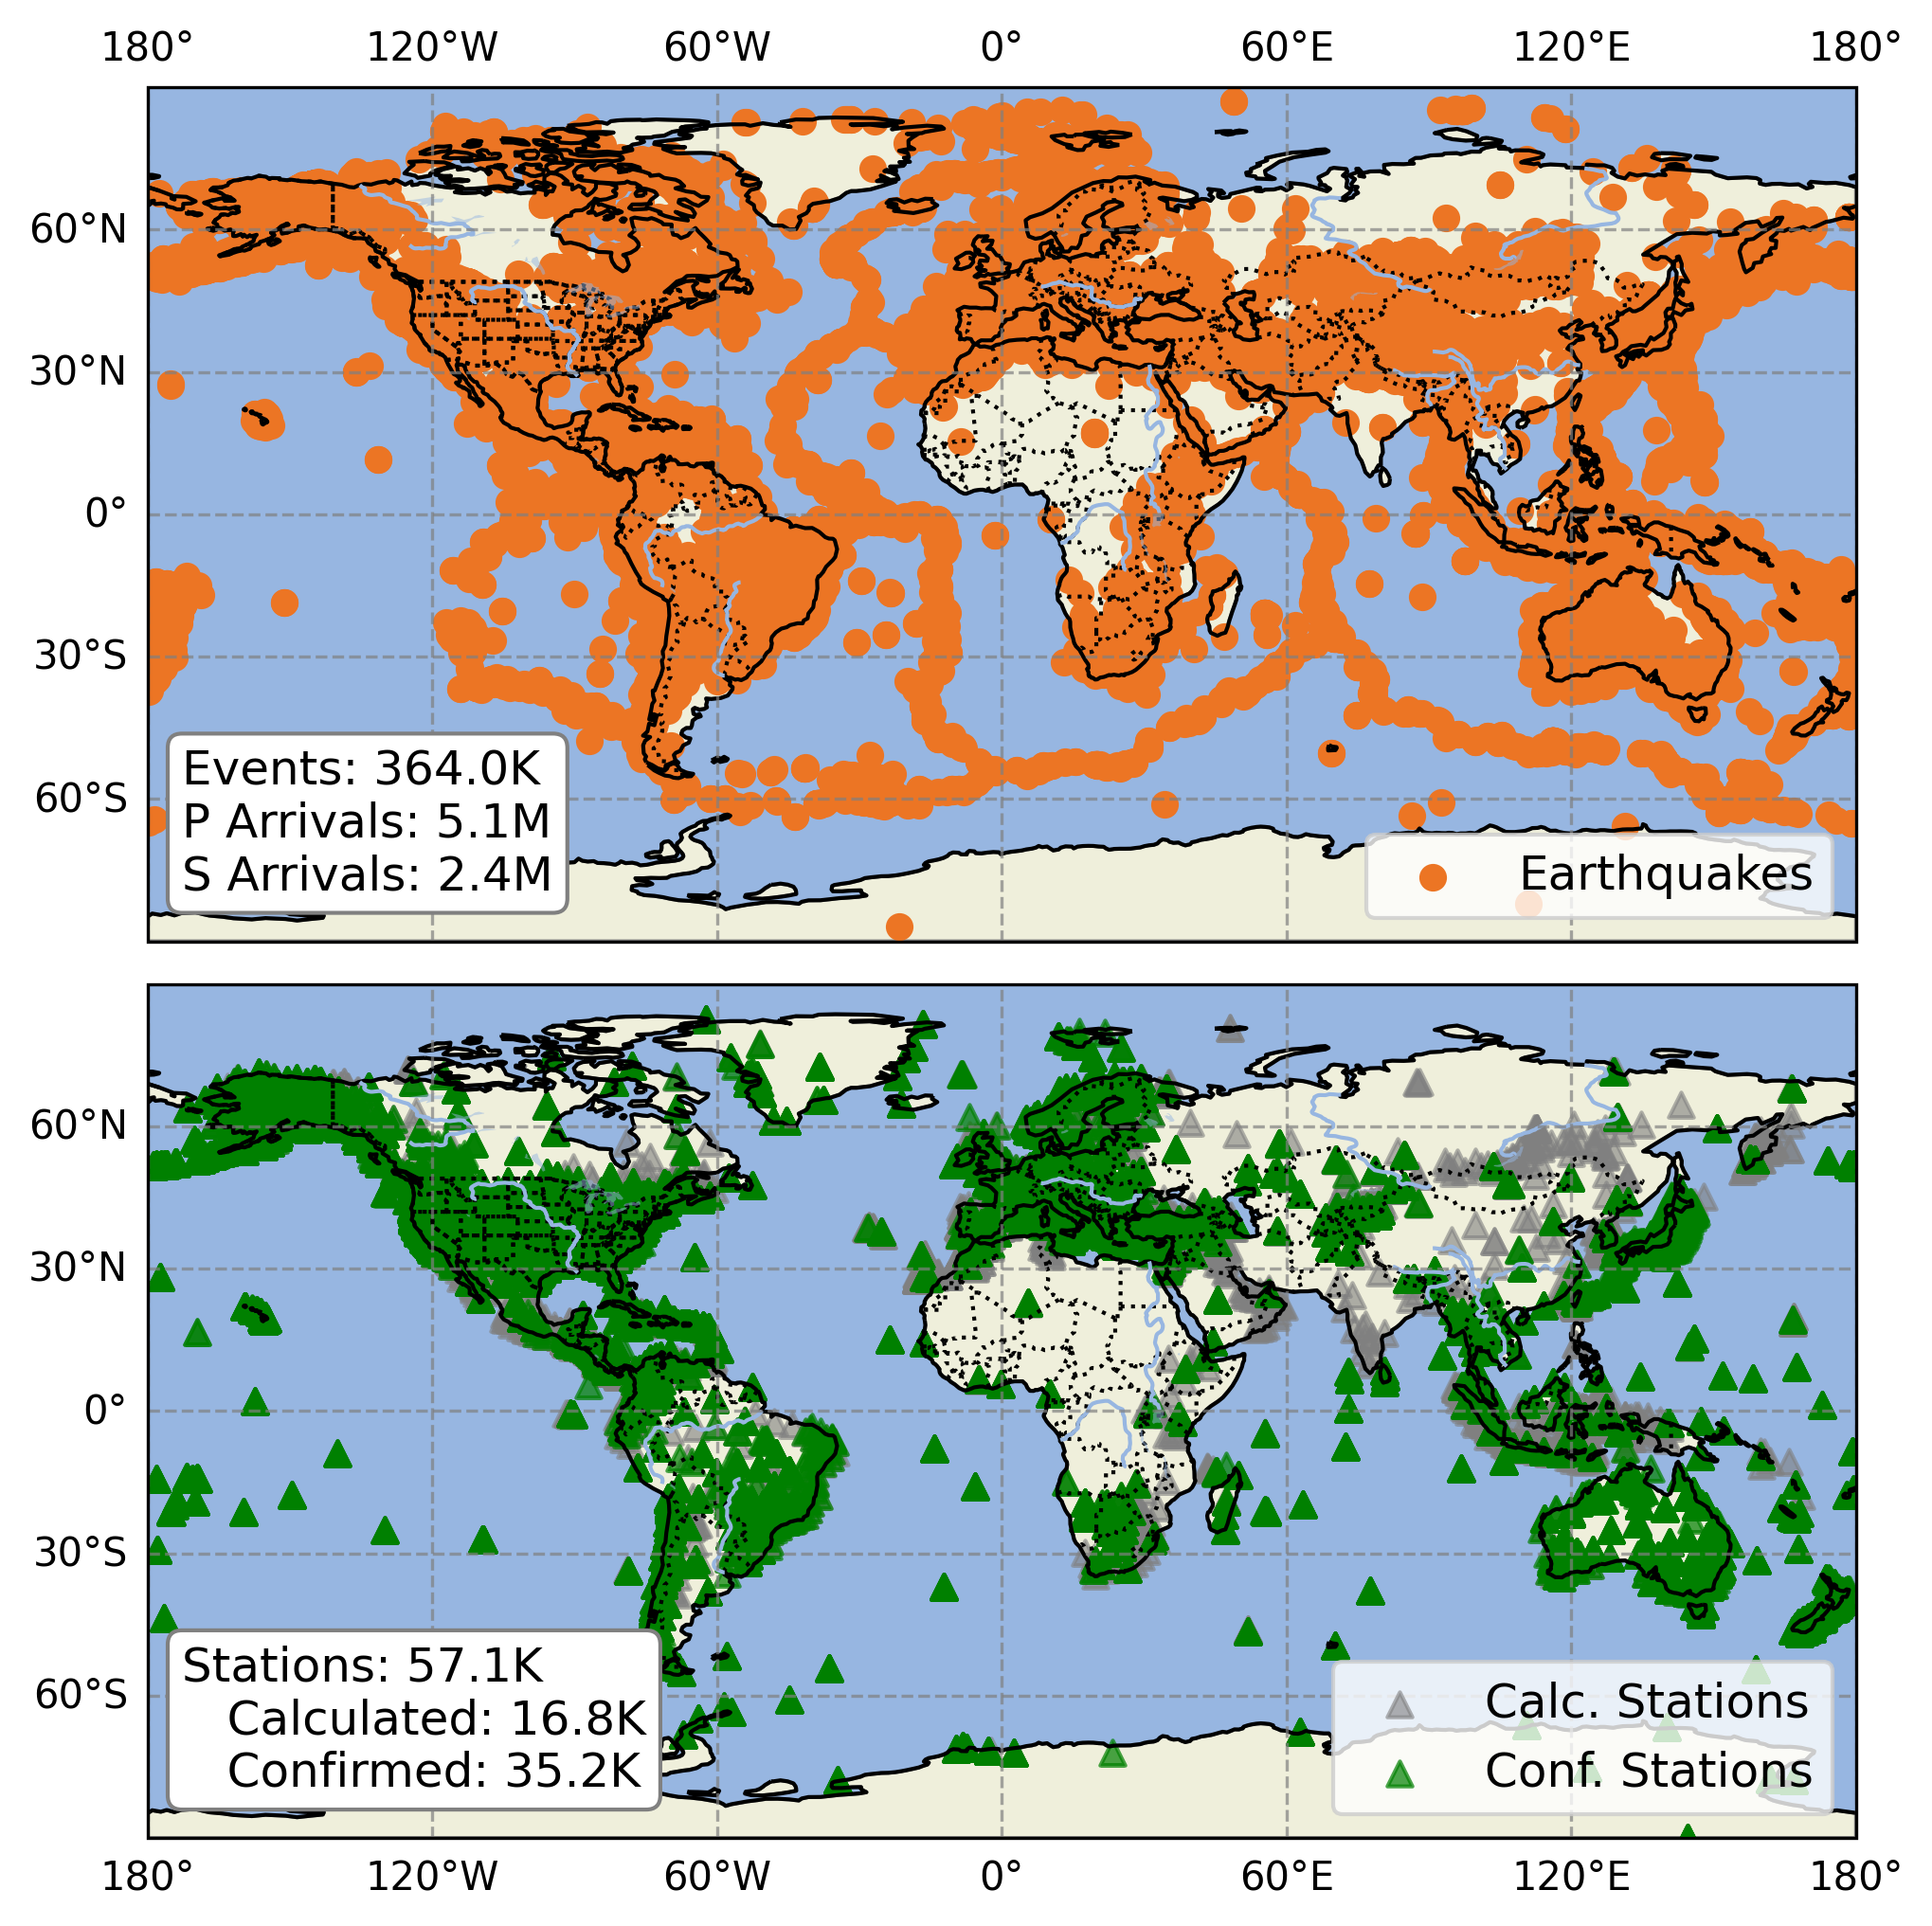

In [ ]:
dataset.plot_overview(savepath="utdquake.png")

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Do

Saved plot to overview.png


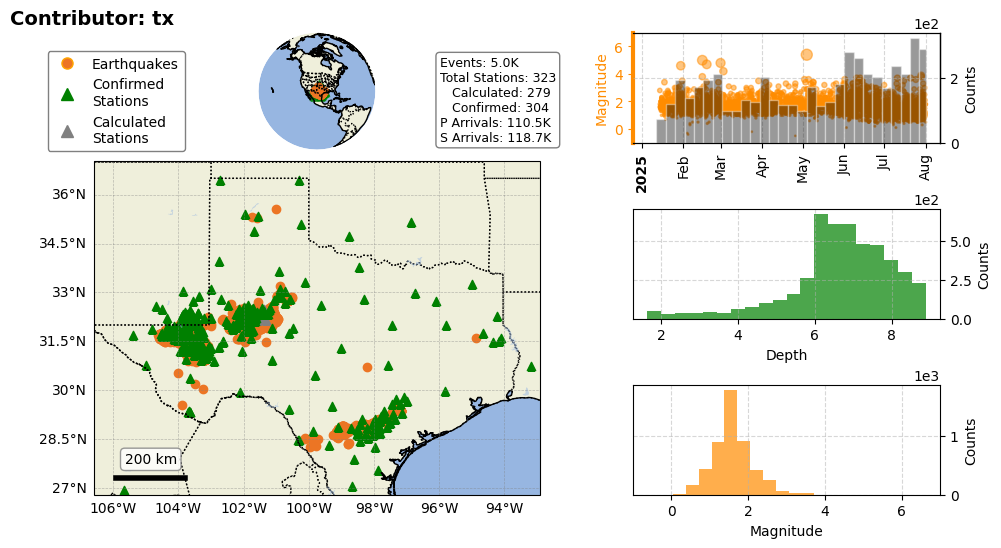

In [ ]:
network = dataset.get_network(name="tx")
network.plot_overview(savepath="overview.png")

Saved plot to uncertainty_boxplots.png


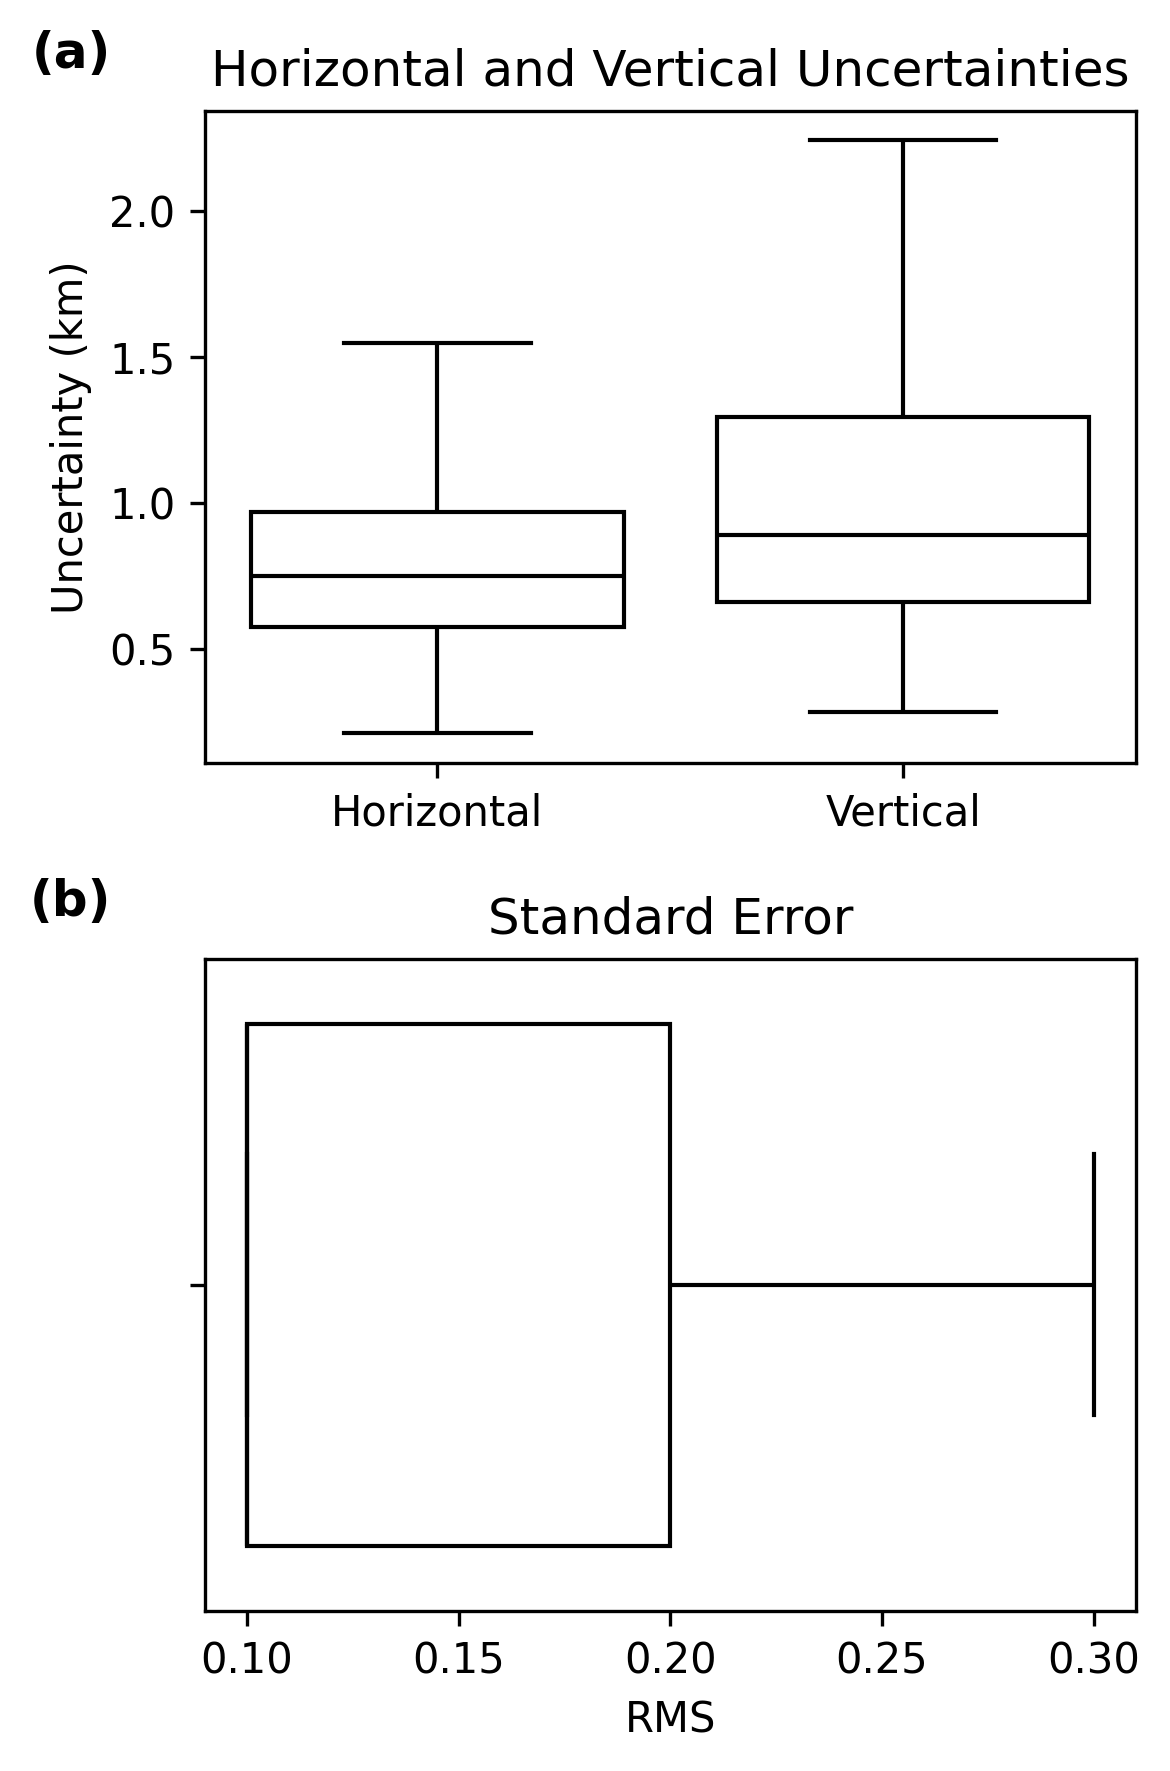

In [ ]:
network.plot_uncertainty_boxplots(savepath="uncertainty_boxplots.png")

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved plot to station_location_uncertainty.png
Saved plot to station_location_uncertainty_map.png


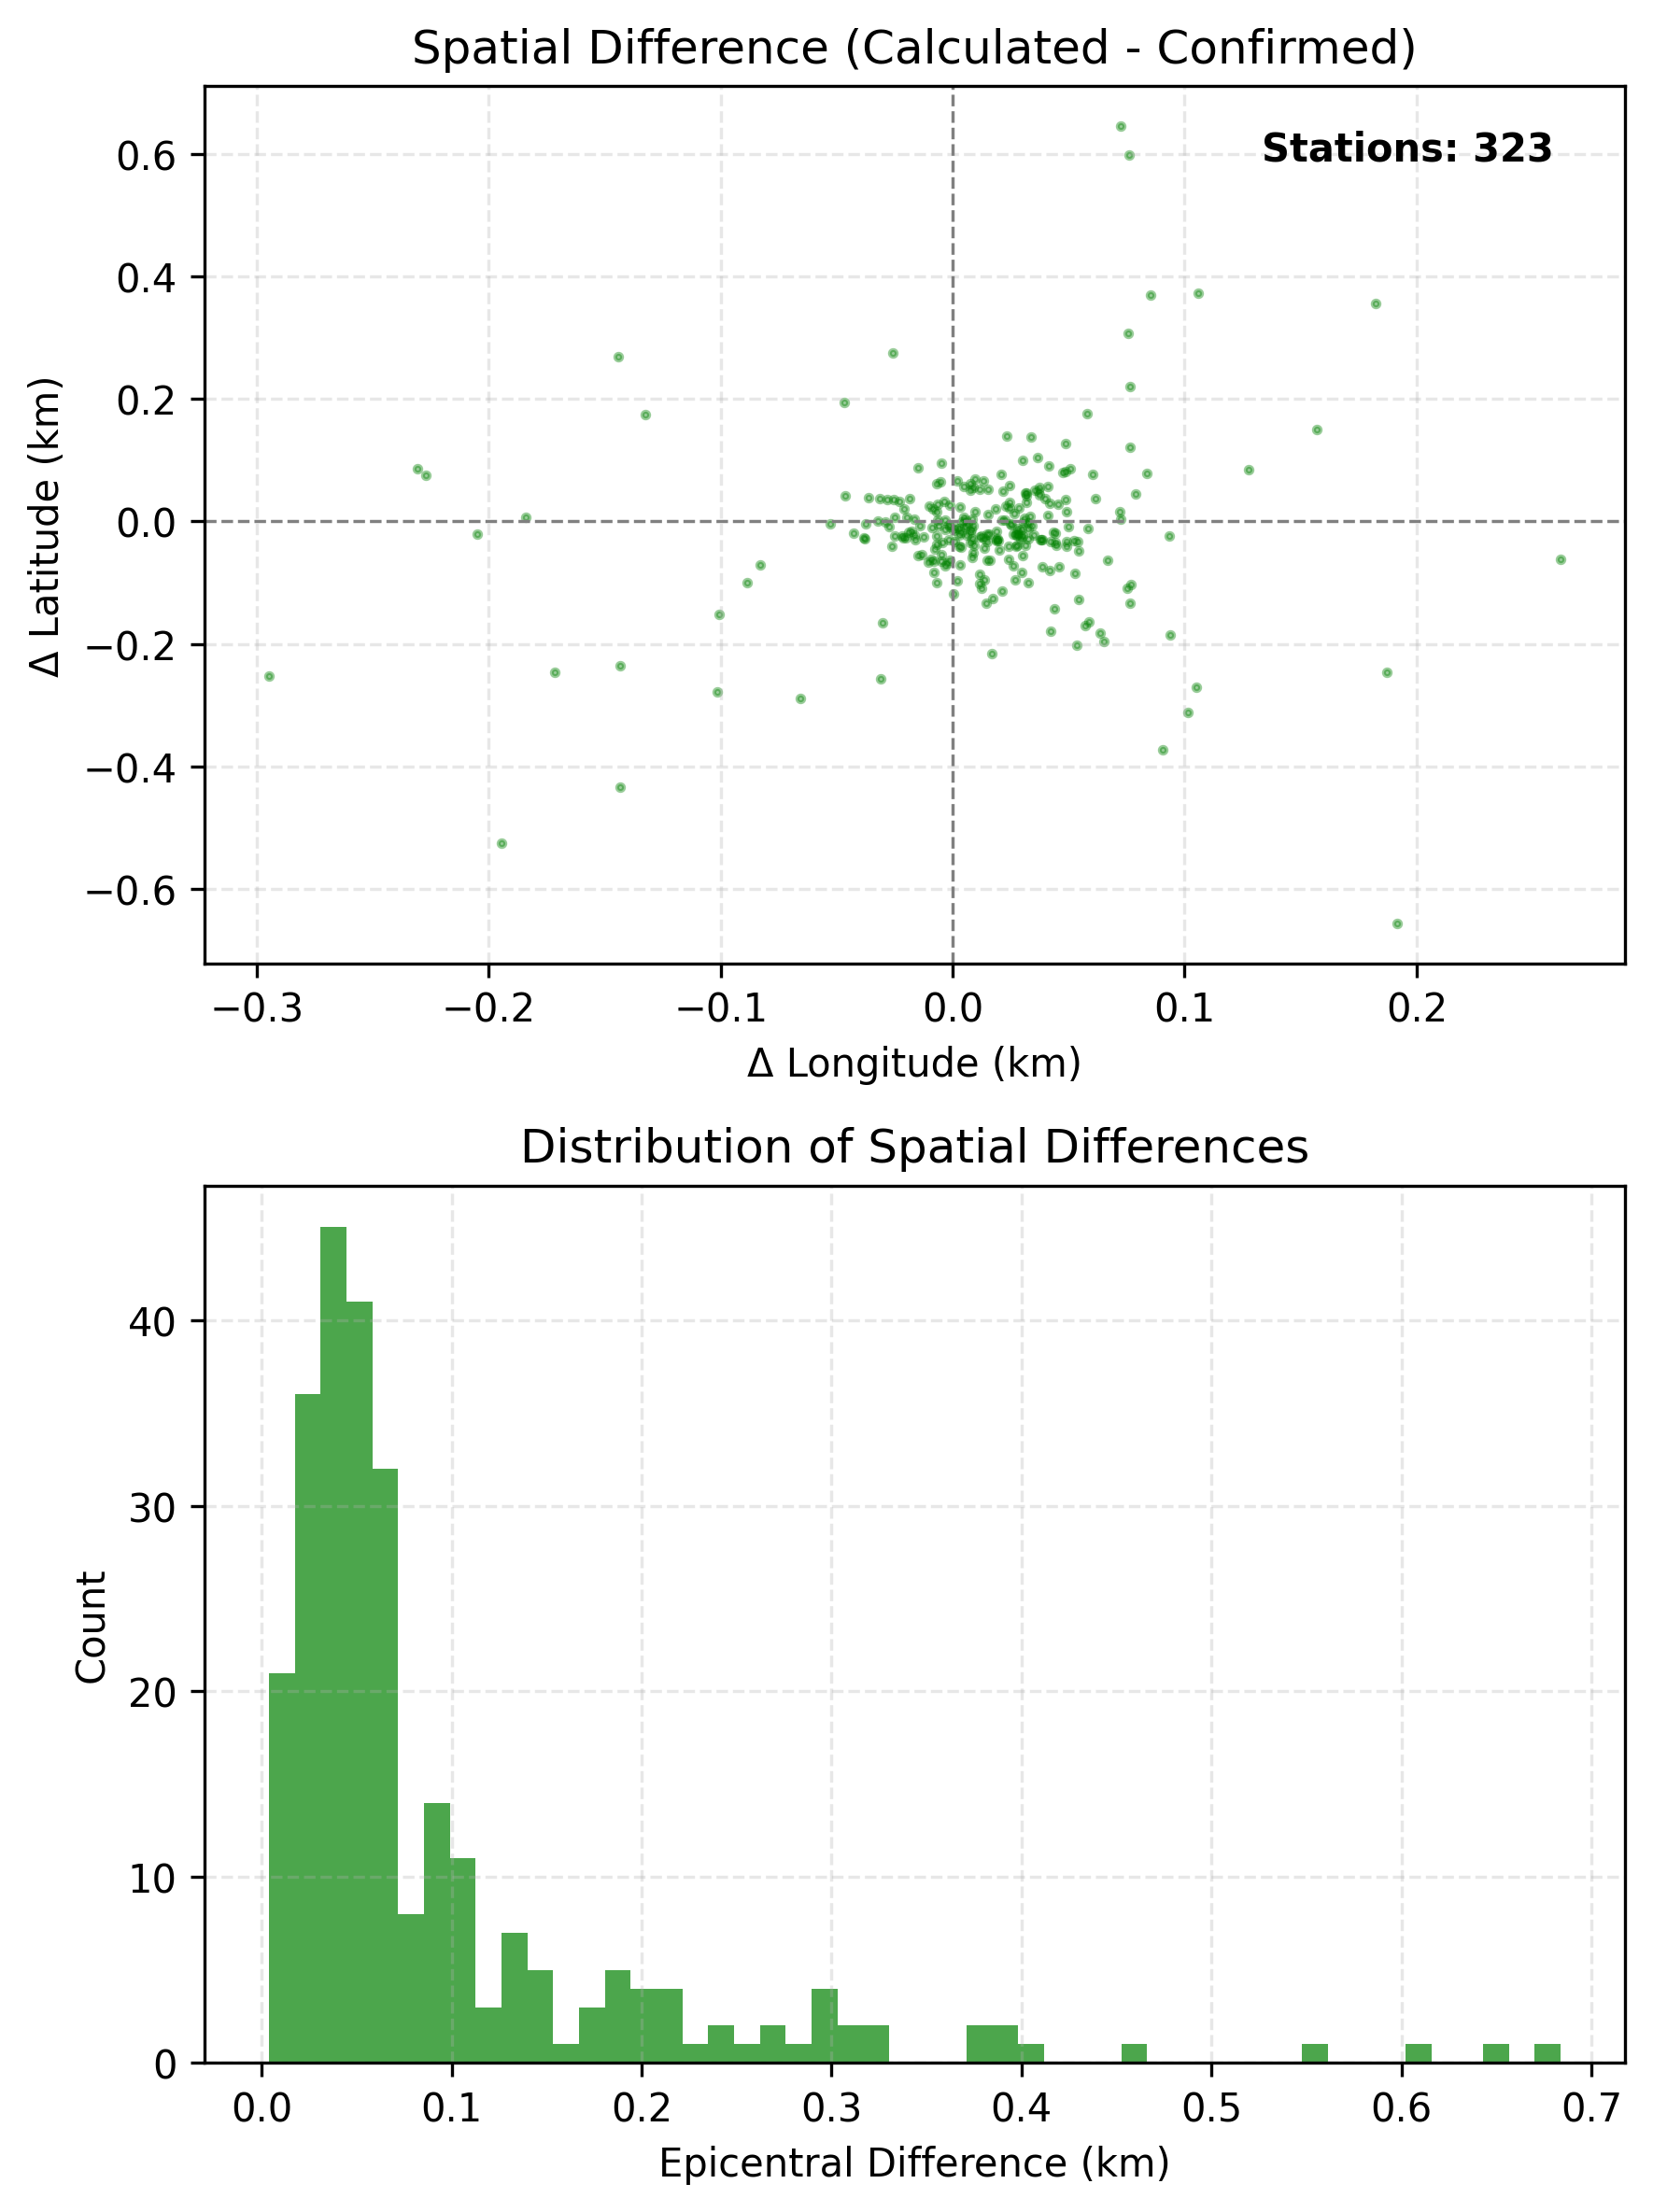

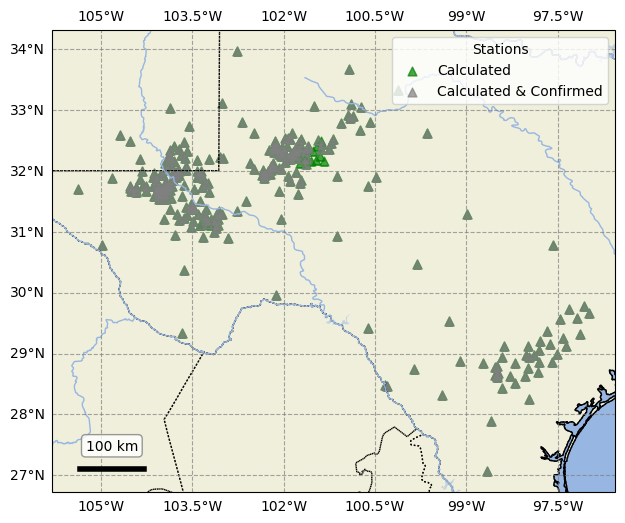

In [ ]:
network.plot_station_location_uncertainty(savepath="station_location_uncertainty.png")

/usr/local/lib/python3.12/dist-packages/utdquake/utils/plot.py:1088: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved plot to stats.png


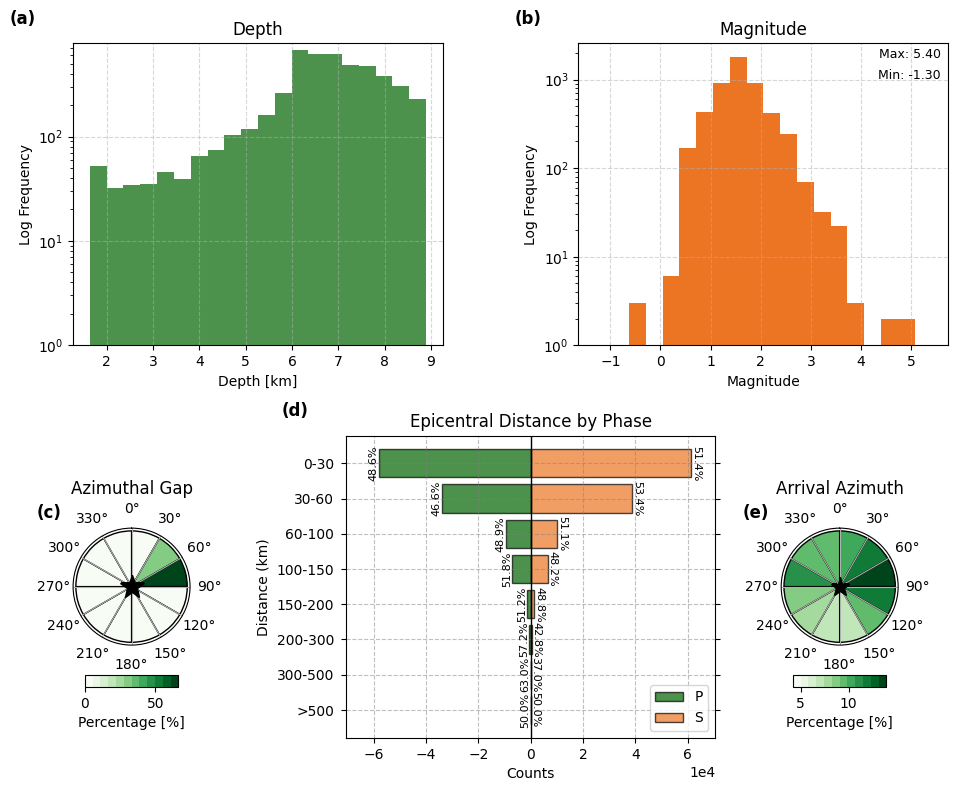

(<Figure size 1000x800 with 7 Axes>,
 {'depth': <Axes: title={'center': 'Depth'}, xlabel='Depth [km]', ylabel='Log Frequency'>,
  'magnitude': <Axes: title={'center': 'Magnitude'}, xlabel='Magnitude', ylabel='Log Frequency'>,
  'epicentral_distance': <Axes: title={'center': 'Epicentral Distance by Phase'}, xlabel='Counts', ylabel='Distance (km)'>,
  'azimuthal_gap': <PolarAxes: title={'center': 'Azimuthal Gap'}>,
  'azimuth': <PolarAxes: title={'center': 'Arrival Azimuth'}>})

In [10]:
network.plot_stats(savepath="stats.png")

/usr/local/lib/python3.12/dist-packages/utdquake/utils/plot.py:1166: UserWarning: No Vp/Vs calculation for origin smi:org.gfz-potsdam.de/geofon/Origin/20250629231132.024312.51486. Not enough valid points for linear regression. 
  warnings.warn(f"No Vp/Vs calculation for origin {origin_id}. Not enough valid points for linear regression. ")
/usr/local/lib/python3.12/dist-packages/utdquake/utils/plot.py:1166: UserWarning: No Vp/Vs calculation for origin smi:org.gfz-potsdam.de/geofon/Origin/20250711150619.368201.156173760. Not enough valid points for linear regression. 
  warnings.warn(f"No Vp/Vs calculation for origin {origin_id}. Not enough valid points for linear regression. ")
/usr/local/lib/python3.12/dist-packages/utdquake/utils/plot.py:1218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([abs(int(y)) for y in yticks])


Saved plot to histograms.png


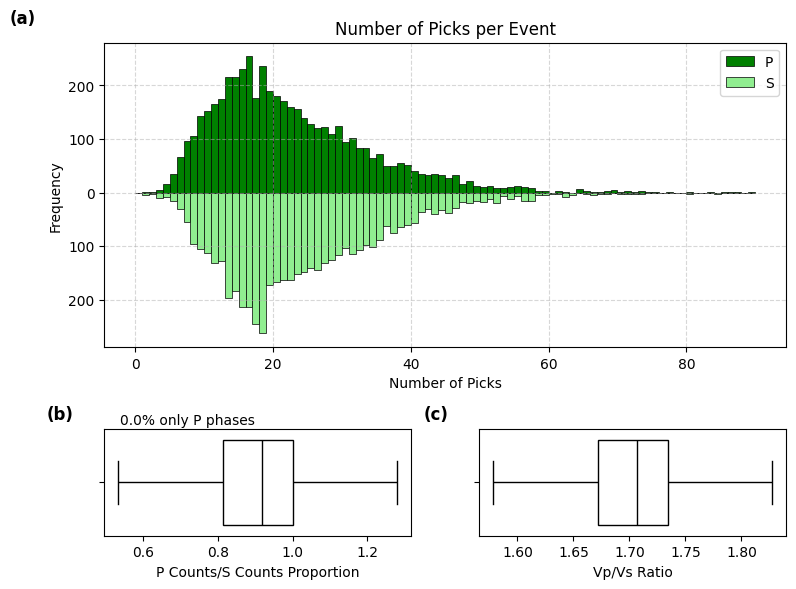

In [ ]:
network.plot_pick_histograms(savepath="histograms.png")

Saved plot to pick_stats.png


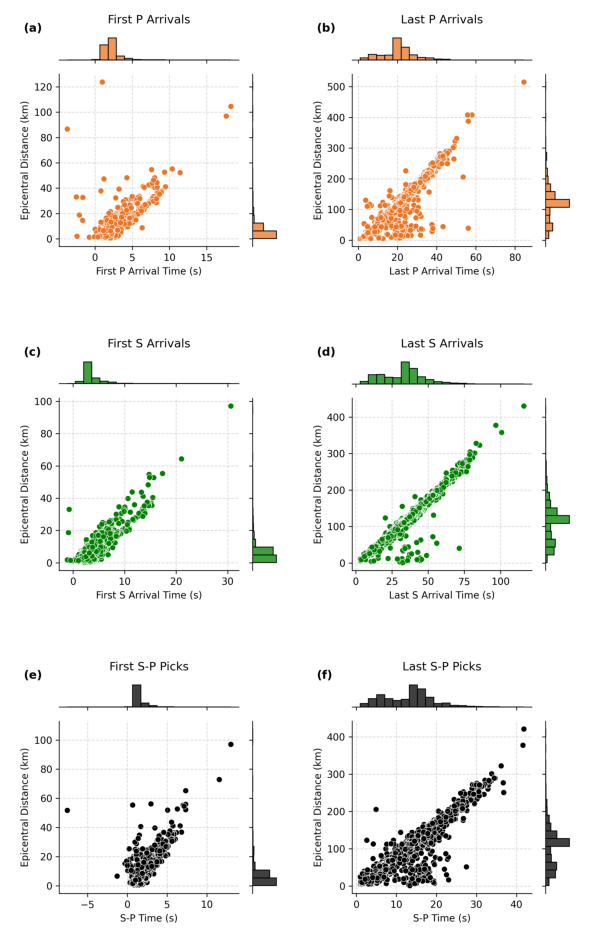

In [ ]:
network.plot_pick_stats(savepath="pick_stats.png")

# Author(s):

<table>
  <tr>
    <td valign="middle">
      <strong>Emmanuel Castillo</strong><br>
      University of Texas at Dallas<br>
      <a href="https://www.linkedin.com/in/ecastillot/" target="_blank">
        <img src="https://img.shields.io/badge/LinkedIn-Follow-blue?logo=linkedin&logoColor=white&style=flat" height="20">
      </a>
      <a href="mailto:castillo.280997@gmail.com" target="_blank">
        <img src="https://img.shields.io/badge/Email-Send-red?logo=gmail&logoColor=white&style=flat" height="20">
      </a>
    </td>
    <td width="100" align="center">
      <img src="https://raw.githubusercontent.com/ecastillot/UTDQuake/main/docs/source/_static/photos/emmanuel.jpg" alt="Emmanuel" width="80" height="80" style="border-radius:50%; object-fit:cover;">
    </td>
  </tr>
  <tr>
    <td valign="middle">
      <strong>Nadine Ushakov</strong><br>
      University of Texas at Dallas<br>
      <a href="https://www.linkedin.com/in/nadineushakov/" target="_blank">
        <img src="https://img.shields.io/badge/LinkedIn-Follow-blue?logo=linkedin&logoColor=white&style=flat" height="20">
      </a>
      <a href="mailto:nadine.igonin@utdallas.edu" target="_blank">
        <img src="https://img.shields.io/badge/Email-Send-red?logo=gmail&logoColor=white&style=flat" height="20">
      </a>
    </td>
    <td width="100" align="center">
      <img src="https://raw.githubusercontent.com/ecastillot/UTDQuake/main/docs/source/_static/photos/nadine.jpg" alt="Nadine" width="80" height="80" style="border-radius:50%; object-fit:cover;">
    </td>
  </tr>
  <tr>
    <td valign="middle">
      <strong>Marine Denolle</strong><br>
      University of Washington<br>
      <a href="https://www.linkedin.com/in/marine-denolle-b528144b/" target="_blank">
        <img src="https://img.shields.io/badge/LinkedIn-Follow-blue?logo=linkedin&logoColor=white&style=flat" height="20">
      </a>
      <a href="mailto:mdenolle@uw.edu" target="_blank">
        <img src="https://img.shields.io/badge/Email-Send-red?logo=gmail&logoColor=white&style=flat" height="20">
      </a>
    </td>
    <td width="100" align="center">
      <img src="https://raw.githubusercontent.com/ecastillot/UTDQuake/main/docs/source/_static/photos/marine.jpg" alt="Marine" width="80" height="80" style="border-radius:50%; object-fit:cover;">
    </td>
  </tr>
</table>

